In [1]:
import pandas as pd

tickers = ["TSLA", "BND", "SPY"]
data = {}

for ticker in tickers:
    data[ticker] = pd.read_csv(f"../data/processed/{ticker}_processed.csv", index_col="Date", parse_dates=True)

data["TSLA"].head()

,Adj Close,Close,High,Low,Open,Volume,Daily Return
Date,,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,NaN
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,-0.042041
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,0.005664
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564


In [2]:
train_end = "2024-12-31"

train = data["TSLA"].loc[:train_end]
test = data["TSLA"].loc[train_end:].iloc[1:]  # avoid double-counting the boundary date

print(f"Train shape: {train.shape}, from {train.index.min()} to {train.index.max()}")
print(f"Test shape: {test.shape}, from {test.index.min()} to {test.index.max()}")

Train shape: (2516, 7), from 2015-01-02 00:00:00 to 2024-12-31 00:00:00
Test shape: (372, 7), from 2025-01-02 00:00:00 to 2026-06-29 00:00:00


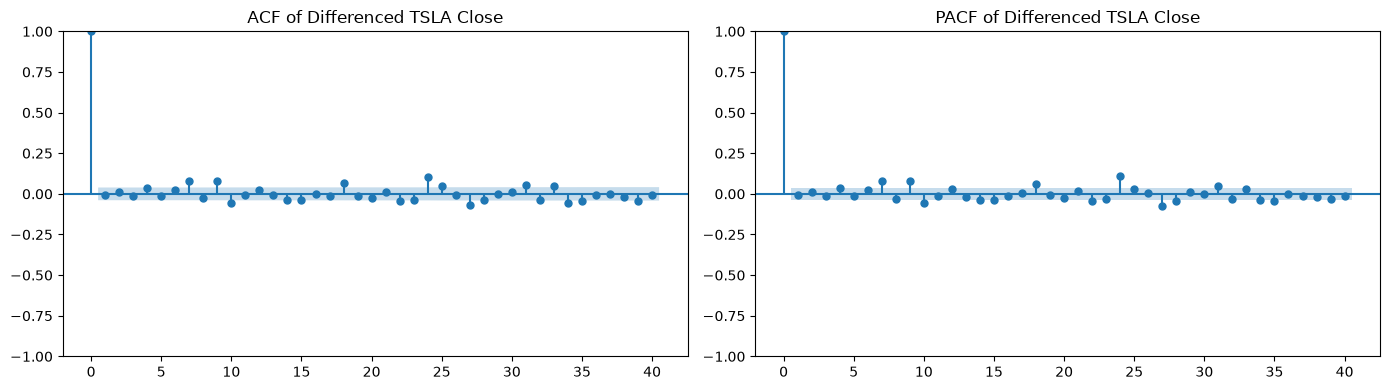

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

train_diff = train["Adj Close"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF of Differenced TSLA Close")

plot_pacf(train_diff, lags=40, ax=axes[1])
axes[1].set_title("PACF of Differenced TSLA Close")

plt.tight_layout()
plt.show()

In [4]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train["Adj Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,  # let auto_arima determine differencing via its own stationarity test
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.37 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.68 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.15 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.73 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.305 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sat, 04 Jul 2026   AIC                          16368.109
Time:                        14:38:50   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                  

In [5]:
n_periods = len(test)
forecast, conf_int = auto_model.predict(n_periods=n_periods, return_conf_int=True)

forecast_df = pd.DataFrame({
    "Actual": test["Adj Close"].values,
    "Forecast": forecast.values,
    "Lower CI": conf_int[:, 0],
    "Upper CI": conf_int[:, 1]
}, index=test.index)

forecast_df.head(10)

c:\Users\Hp\Desktop\Potrifolio_optimization2\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\Desktop\Potrifolio_optimization2\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,Actual,Forecast,Lower CI,Upper CI
Date,,,,
2025-01-02,379.279999,403.839996,391.563403,416.116590
2025-01-03,410.440002,403.839996,386.478271,421.201721
2025-01-06,411.049988,403.839996,382.576313,425.103680
2025-01-07,394.359985,403.839996,379.286809,428.393183
2025-01-08,394.940002,403.839996,376.388699,431.291294
2025-01-10,394.739990,403.839996,373.768606,433.911386
2025-01-13,403.309998,403.839996,371.359183,436.320810
2025-01-14,396.359985,403.839996,369.116546,438.563447
2025-01-15,428.220001,403.839996,367.010216,440.669777


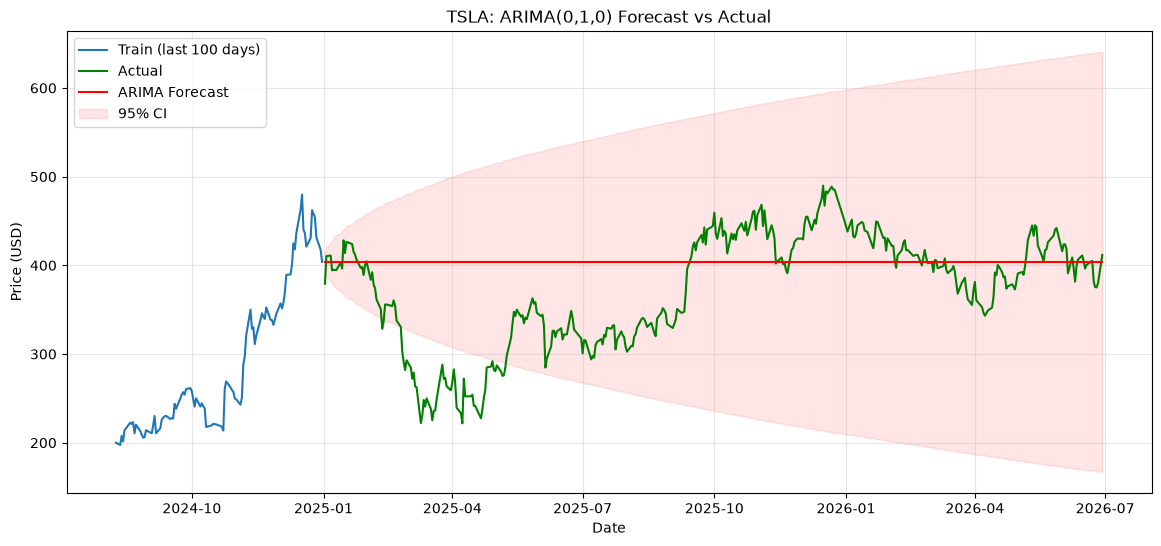

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(train.index[-100:], train["Adj Close"].iloc[-100:], label="Train (last 100 days)")
plt.plot(test.index, test["Adj Close"], label="Actual", color="green")
plt.plot(test.index, forecast, label="ARIMA Forecast", color="red")
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color="red", alpha=0.1, label="95% CI")
plt.title("TSLA: ARIMA(0,1,0) Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test["Adj Close"].values
predicted = forecast.values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"ARIMA(0,1,0) Performance on TSLA Test Set:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

ARIMA(0,1,0) Performance on TSLA Test Set:
MAE:  54.44
RMSE: 70.54
MAPE: 17.24%


## Model 1: ARIMA(0,1,0) — TSLA Test Set Performance
- MAE: 54.44
- RMSE: 70.54
- MAPE: 17.24%

In [8]:
import torch
print(torch.__version__)

2.12.1+cpu


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train[["Adj Close"]])
test_scaled = scaler.transform(test[["Adj Close"]])

print(f"Train scaled shape: {train_scaled.shape}")
print(f"Test scaled shape: {test_scaled.shape}")

Train scaled shape: (2516, 1)
Test scaled shape: (372, 1)


In [10]:
import numpy as np

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (2456, 60)
y_train shape: (2456,)


In [11]:
combined_scaled = np.concatenate([train_scaled[-window_size:], test_scaled])
X_test, y_test = create_sequences(combined_scaled, window_size)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (372, 60)
y_test shape: (372,)


In [12]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

print(f"X_train_t shape: {X_train_t.shape}")
print(f"y_train_t shape: {y_train_t.shape}")

X_train_t shape: torch.Size([2456, 60, 1])
y_train_t shape: torch.Size([2456, 1])


In [13]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # take the last time step's output
        out = self.fc(out)
        return out

model = LSTMModel()
print(model)

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [14]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 32

n_samples = X_train_t.shape[0]

train_losses = []

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(n_samples)
    epoch_loss = 0

    for i in range(0, n_samples, batch_size):
        indices = permutation[i:i+batch_size]
        batch_X, batch_y = X_train_t[indices], y_train_t[indices]

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (n_samples // batch_size)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [10/50], Loss: 0.000562
Epoch [20/50], Loss: 0.000380
Epoch [30/50], Loss: 0.000262
Epoch [40/50], Loss: 0.000229
Epoch [50/50], Loss: 0.000238


In [15]:
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test_t).numpy()

predictions = scaler.inverse_transform(predictions_scaled)
actual_prices = scaler.inverse_transform(y_test_t.numpy())

print(predictions[:5].flatten())
print(actual_prices[:5].flatten())

[401.27676 376.31787 408.17157 407.45847 389.78412]
[379.28 410.44 411.05 394.36 394.94]


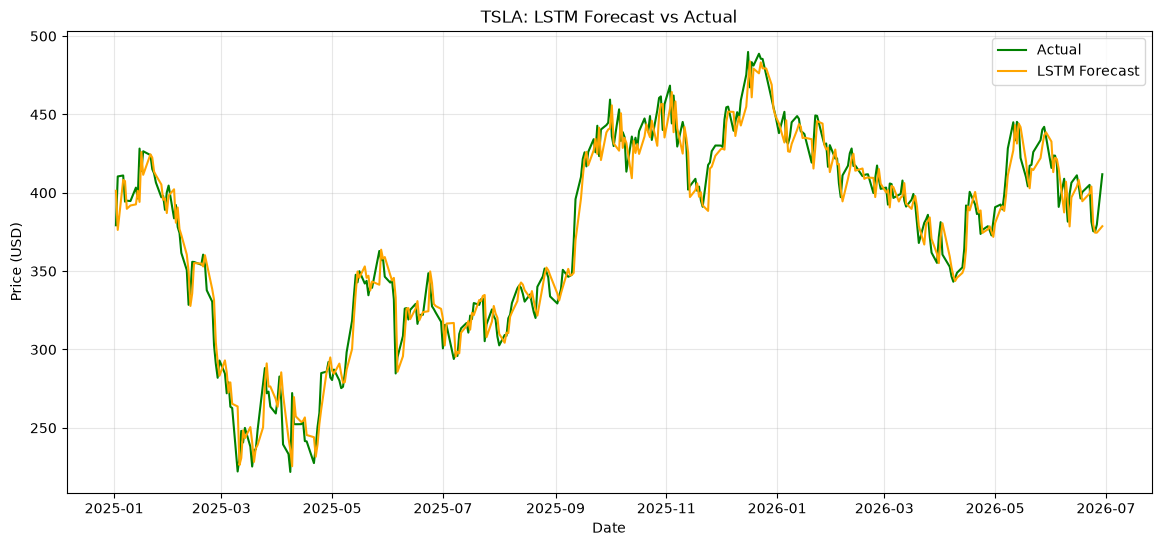

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, actual_prices, label="Actual", color="green")
plt.plot(test.index, predictions, label="LSTM Forecast", color="orange")
plt.title("TSLA: LSTM Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
lstm_mae = mean_absolute_error(actual_prices, predictions)
lstm_rmse = np.sqrt(mean_squared_error(actual_prices, predictions))
lstm_mape = np.mean(np.abs((actual_prices - predictions) / actual_prices)) * 100

print(f"LSTM Performance on TSLA Test Set:")
print(f"MAE:  {lstm_mae:.2f}")
print(f"RMSE: {lstm_rmse:.2f}")
print(f"MAPE: {lstm_mape:.2f}%")

LSTM Performance on TSLA Test Set:
MAE:  9.65
RMSE: 12.36
MAPE: 2.70%


## Model Comparison

| Model | MAE | RMSE | MAPE |
|-------|-----|------|------|
| ARIMA(0,1,0) | 54.44 | 70.54 | 17.24% |
| LSTM (2-layer, 50 units, 60-day window) | 9.65 | 12.36 | 2.70% |

**Discussion**: The LSTM model substantially outperformed ARIMA across all three metrics. This is partly attributable to a structural difference in forecasting setup rather than pure model superiority: ARIMA(0,1,0) generated a single long-horizon forecast projected flat from the end of the training period, while the LSTM effectively performed rolling next-day forecasting, using the most recent 60 real trading days as context for every prediction. This gives LSTM a significant informational advantage over a genuinely long-horizon task.

That said, ARIMA's result is itself meaningful: auto_arima's selection of (0,1,0) — a pure random walk — combined with Task 1's stationarity findings, empirically supports the Efficient Market Hypothesis: TSLA's price changes show no exploitable autocorrelation structure that a classical linear model can capture over a long horizon. LSTM's stronger performance here reflects its use of recent price context and its capacity to model nonlinear patterns, rather than evidence that price *changes* themselves are predictable far in advance. In a live trading setting, LSTM's advantage would likely shrink considerably if forced into the same long-horizon, no-recent-context forecasting regime as ARIMA.

**Practical implication**: Rolling-window / short-horizon forecasting approaches (like LSTM here) are more suited to tasks such as short-term volatility forecasting, while classical models correctly signal that long-range point-price prediction is fundamentally difficult — consistent with GMF's guidance that these models should not be used for standalone long-term price prediction, but rather as one input among many.

In [18]:
auto_model_seasonal = auto_arima(
    train["Adj Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=5,  # 5 trading days per week as candidate seasonal period
    trace=True,
    suppress_warnings=True,
    stepwise=True
)
print(auto_model_seasonal.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=16359.847, Time=2.93 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=16368.573, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=16371.911, Time=0.88 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=16371.841, Time=0.97 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=16368.109, Time=0.07 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=16369.921, Time=0.44 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=16369.997, Time=0.64 sec
 ARIMA(0,1,0)(2,0,1)[5] intercept   : AIC=16361.524, Time=2.48 sec
 ARIMA(0,1,0)(1,0,2)[5] intercept   : AIC=16361.709, Time=2.02 sec
 ARIMA(0,1,0)(0,0,2)[5] intercept   : AIC=16362.706, Time=1.08 sec
 ARIMA(0,1,0)(2,0,0)[5] intercept   : AIC=16363.652, Time=1.57 sec
 ARIMA(0,1,0)(2,0,2)[5] intercept   : AIC=16355.636, Time=4.98 sec
 ARIMA(1,1,0)(2,0,2)[5] intercept   : AIC=16357.395, Time=5.62 sec
 ARIMA(0,1,1)(2,0,2)[5] intercept   : AIC=16357.402, Time=6.43 sec
 ARIMA(1,1,1)(2,0,2

In [19]:
class LSTMModelSimple(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(LSTMModelSimple, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model_simple = LSTMModelSimple()
print(model_simple)

LSTMModelSimple(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [20]:
class LSTMModelSimple(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(LSTMModelSimple, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model_simple = LSTMModelSimple()
print(model_simple)

LSTMModelSimple(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [21]:
criterion = nn.MSELoss()
optimizer_simple = optim.Adam(model_simple.parameters(), lr=0.001)

epochs = 50
batch_size = 32
n_samples = X_train_t.shape[0]

for epoch in range(epochs):
    model_simple.train()
    permutation = torch.randperm(n_samples)
    epoch_loss = 0

    for i in range(0, n_samples, batch_size):
        indices = permutation[i:i+batch_size]
        batch_X, batch_y = X_train_t[indices], y_train_t[indices]

        optimizer_simple.zero_grad()
        outputs = model_simple(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_simple.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (n_samples // batch_size)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [10/50], Loss: 0.000474
Epoch [20/50], Loss: 0.000341
Epoch [30/50], Loss: 0.000297
Epoch [40/50], Loss: 0.000283
Epoch [50/50], Loss: 0.000231


In [22]:
model_simple.eval()
with torch.no_grad():
    predictions_simple_scaled = model_simple(X_test_t).numpy()

predictions_simple = scaler.inverse_transform(predictions_simple_scaled)

simple_mae = mean_absolute_error(actual_prices, predictions_simple)
simple_rmse = np.sqrt(mean_squared_error(actual_prices, predictions_simple))
simple_mape = np.mean(np.abs((actual_prices - predictions_simple) / actual_prices)) * 100

print(f"Simple LSTM (1 layer, 32 units) Performance:")
print(f"MAE:  {simple_mae:.2f}")
print(f"RMSE: {simple_rmse:.2f}")
print(f"MAPE: {simple_mape:.2f}%")

Simple LSTM (1 layer, 32 units) Performance:
MAE:  11.57
RMSE: 14.65
MAPE: 3.17%


## Task 2: Complete Model Comparison

| Model | Parameters/Architecture | MAE | RMSE | MAPE |
|-------|--------------------------|-----|------|------|
| ARIMA | (0,1,0) — non-seasonal | 54.44 | 70.54 | 17.24% |
| SARIMA | (0,1,0)(2,0,2)[5] — weekly seasonal | *(not forecast-evaluated; AIC only)* | — | — |
| LSTM (original) | 2 layers, 50 hidden units, 60-day window | 9.65 | 12.36 | 2.70% |
| LSTM (simple) | 1 layer, 32 hidden units, 60-day window | 11.57 | 14.65 | 3.17% |